# Football Player Rating Prediction

In [1]:
import pandas as pd

In [51]:
df = pd.read_csv("../player-OVR/datasets/players_fifa22.csv")

In [52]:
df.head()

,ID,Name,FullName,Age,Height,Weight,PhotoUrl,Nationality,Overall,Potential,...,LMRating,CMRating,RMRating,LWBRating,CDMRating,RWBRating,LBRating,CBRating,RBRating,GKRating
0,158023,L. Messi,Lionel Messi,34,170,72,https://cdn.sofifa.com/players/158/023/22_60.png,Argentina,93,93,...,93,90,93,69,67,69,64,53,64,22
1,188545,R. Lewandowski,Robert Lewandowski,32,185,81,https://cdn.sofifa.com/players/188/545/22_60.png,Poland,92,92,...,87,83,87,67,69,67,64,63,64,22
2,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,36,187,83,https://cdn.sofifa.com/players/020/801/22_60.png,Portugal,91,91,...,89,81,89,66,62,66,63,56,63,23
3,231747,K. Mbappé,Kylian Mbappé,22,182,73,https://cdn.sofifa.com/players/231/747/22_60.png,France,91,95,...,92,84,92,70,66,70,66,57,66,21
4,200389,J. Oblak,Jan Oblak,28,188,87,https://cdn.sofifa.com/players/200/389/22_60.png,Slovenia,91,93,...,38,41,38,35,39,35,35,36,35,92


In [53]:
df.describe()

,ID,Age,Height,Weight,Overall,Potential,Growth,TotalStats,BaseStats,ValueEUR,...,LMRating,CMRating,RMRating,LWBRating,CDMRating,RWBRating,LBRating,CBRating,RBRating,GKRating
count,19260.000000,19260.000000,19260.000000,19260.000000,19260.000000,19260.000000,19260.000000,19260.000000,19260.000000,1.926000e+04,...,19260.000000,19260.000000,19260.000000,19260.000000,19260.000000,19260.000000,19260.000000,19260.000000,19260.000000,19260.000000
mean,231682.741952,25.184683,181.305036,74.950779,65.815628,71.100104,5.284476,1598.525909,357.062461,2.857652e+06,...,58.364434,57.227207,58.364434,56.197040,55.771340,56.197040,55.539823,54.379595,55.539823,23.242939
std,26960.272515,4.737340,6.866151,7.066864,6.817297,6.092103,5.472201,271.575855,39.910613,7.604532e+06,...,13.989045,13.212152,13.989045,13.818416,13.856922,13.818416,14.063862,14.678658,14.063862,15.053823
min,41.000000,16.000000,155.000000,49.000000,48.000000,49.000000,0.000000,767.000000,227.000000,0.000000e+00,...,17.000000,17.000000,17.000000,17.000000,18.000000,17.000000,16.000000,18.000000,16.000000,10.000000
25%,214903.500000,21.000000,176.000000,70.000000,62.000000,67.000000,0.000000,1462.000000,329.000000,4.750000e+05,...,54.000000,52.000000,54.000000,51.000000,48.000000,51.000000,49.000000,44.000000,49.000000,17.000000
50%,236687.500000,25.000000,181.000000,75.000000,66.000000,71.000000,4.000000,1633.000000,358.000000,9.750000e+05,...,62.000000,60.000000,62.000000,59.000000,59.000000,59.000000,59.000000,58.000000,59.000000,18.000000
75%,253607.500000,29.000000,186.000000,80.000000,70.000000,75.000000,9.000000,1782.000000,384.000000,2.000000e+06,...,67.000000,66.000000,67.000000,65.000000,66.000000,65.000000,65.000000,66.000000,65.000000,20.000000
max,264705.000000,54.000000,206.000000,110.000000,93.000000,95.000000,26.000000,2341.000000,501.000000,1.940000e+08,...,93.000000,91.000000,93.000000,88.000000,90.000000,88.000000,88.000000,89.000000,88.000000,92.000000


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19260 entries, 0 to 19259
Data columns (total 90 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 19260 non-null  int64  
 1   Name               19260 non-null  object 
 2   FullName           19260 non-null  object 
 3   Age                19260 non-null  int64  
 4   Height             19260 non-null  int64  
 5   Weight             19260 non-null  int64  
 6   PhotoUrl           19260 non-null  object 
 7   Nationality        19260 non-null  object 
 8   Overall            19260 non-null  int64  
 9   Potential          19260 non-null  int64  
 10  Growth             19260 non-null  int64  
 11  TotalStats         19260 non-null  int64  
 12  BaseStats          19260 non-null  int64  
 13  Positions          19260 non-null  object 
 14  BestPosition       19260 non-null  object 
 15  Club               19260 non-null  object 
 16  ValueEUR           192

## Data Exploration & Cleaning

In [55]:
df[[
    "Overall",
    "Age",
    "PaceTotal",
    "ShootingTotal",
    "PassingTotal",
    "DribblingTotal",
    "DefendingTotal",
    "PhysicalityTotal"
]].isnull().sum()

Overall             0
Age                 0
PaceTotal           0
ShootingTotal       0
PassingTotal        0
DribblingTotal      0
DefendingTotal      0
PhysicalityTotal    0
dtype: int64

In [56]:
df.duplicated().sum()

104

In [57]:
df = df.drop_duplicates()

In [58]:
df.shape

(19156, 90)

In [59]:
df.duplicated().sum()

0

In [60]:
df[[
    "Overall",
    "Age",
    "PaceTotal",
    "ShootingTotal",
    "PassingTotal",
    "DribblingTotal",
    "DefendingTotal",
    "PhysicalityTotal"
]].describe()

,Overall,Age,PaceTotal,ShootingTotal,PassingTotal,DribblingTotal,DefendingTotal,PhysicalityTotal
count,19156.000000,19156.000000,19156.000000,19156.000000,19156.000000,19156.000000,19156.000000,19156.000000
mean,65.765765,25.190750,67.873095,53.499478,57.805857,62.978545,50.012842,64.644968
std,6.802014,4.743117,10.654588,13.806390,9.828530,9.691676,16.367141,9.626229
min,48.000000,16.000000,28.000000,18.000000,25.000000,26.000000,14.000000,29.000000
25%,61.000000,21.000000,62.000000,44.000000,51.000000,58.000000,35.000000,58.000000
50%,66.000000,25.000000,68.000000,56.000000,58.000000,64.000000,54.000000,66.000000
75%,70.000000,29.000000,75.000000,64.000000,64.000000,69.000000,63.000000,72.000000
max,93.000000,54.000000,97.000000,94.000000,93.000000,95.000000,91.000000,92.000000


In [61]:
df[[
    "Overall",
    "Age",
    "PaceTotal",
    "ShootingTotal",
    "PassingTotal",
    "DribblingTotal",
    "DefendingTotal",
    "PhysicalityTotal"
]].corr()

,Overall,Age,PaceTotal,ShootingTotal,PassingTotal,DribblingTotal,DefendingTotal,PhysicalityTotal
Overall,1.000000,0.451999,0.242933,0.472543,0.696286,0.652533,0.356793,0.569496
Age,0.451999,1.000000,-0.158279,0.263086,0.350565,0.204788,0.222665,0.443186
PaceTotal,0.242933,-0.158279,1.000000,0.314570,0.264026,0.518600,-0.220798,-0.119963
ShootingTotal,0.472543,0.263086,0.314570,1.000000,0.670790,0.773268,-0.418537,0.041281
PassingTotal,0.696286,0.350565,0.264026,0.670790,1.000000,0.829028,0.136817,0.194009
DribblingTotal,0.652533,0.204788,0.518600,0.773268,0.829028,1.000000,-0.138125,0.050118
DefendingTotal,0.356793,0.222665,-0.220798,-0.418537,0.136817,-0.138125,1.000000,0.520447
PhysicalityTotal,0.569496,0.443186,-0.119963,0.041281,0.194009,0.050118,0.520447,1.000000


## Exploratory Data Analysis

In [62]:
features = [
    "Age",
    "PaceTotal",
    "ShootingTotal",
    "PassingTotal",
    "DribblingTotal",
    "DefendingTotal",
    "PhysicalityTotal"
]

df[features + ["Overall"]].corr()["Overall"].sort_values(ascending=False)

Overall             1.000000
PassingTotal        0.696286
DribblingTotal      0.652533
PhysicalityTotal    0.569496
ShootingTotal       0.472543
Age                 0.451999
DefendingTotal      0.356793
PaceTotal           0.242933
Name: Overall, dtype: float64

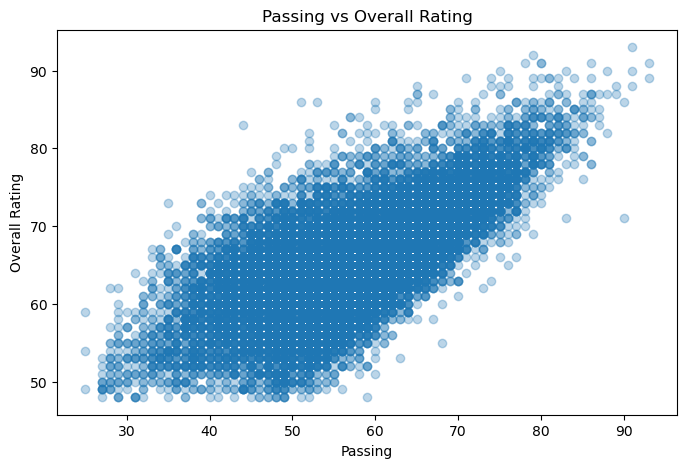

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["PassingTotal"],
    df["Overall"],
    alpha=0.3
)

plt.xlabel("Passing")
plt.ylabel("Overall Rating")
plt.title("Passing vs Overall Rating")

plt.show()

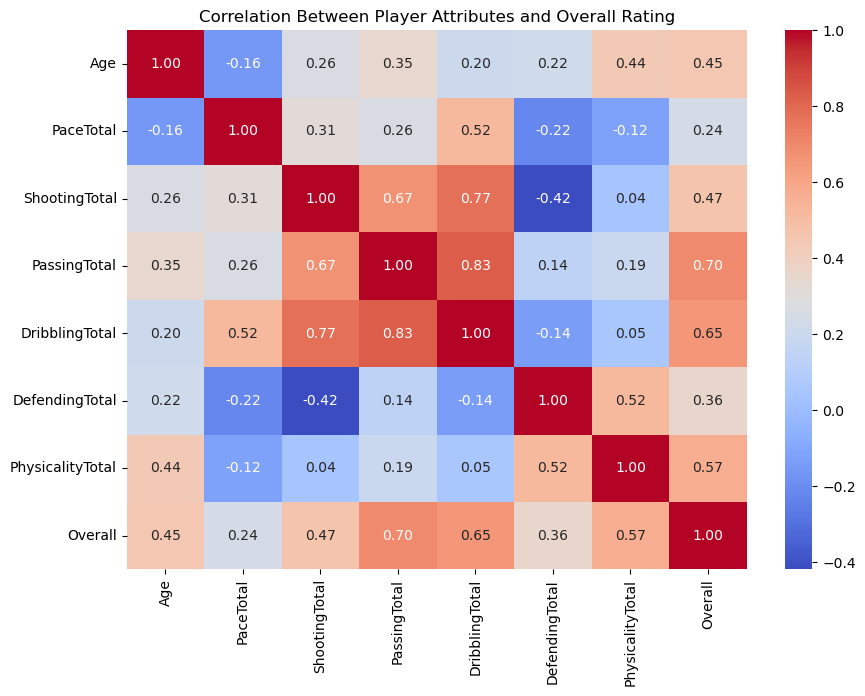

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    "Age",
    "PaceTotal",
    "ShootingTotal",
    "PassingTotal",
    "DribblingTotal",
    "DefendingTotal",
    "PhysicalityTotal",
    "Overall"
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Player Attributes and Overall Rating")
plt.show()

In [65]:
target = "Overall"

In [66]:
X = df[features]
y = df[target]

In [67]:
from sklearn.model_selection import train_test_split

## Linear Regression Baseline

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [69]:
from sklearn.linear_model import LinearRegression

In [70]:
model = LinearRegression()

In [71]:
model.fit(X_train, y_train)

LinearRegression()

In [72]:
y_pred = model.predict(X_test)

In [73]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Age,-2.318382e-16
1,PaceTotal,-6.314958e-16
2,ShootingTotal,2.373942e-16
3,PassingTotal,-2.372573e-15
4,DribblingTotal,2.070225e-15
5,DefendingTotal,5.355822e-16
6,PhysicalityTotal,-2.998266e-16
7,Overall,1.000000e+00


In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.1069781139060016e-14
RMSE: 1.4525375412571845e-14
R²: 1.0


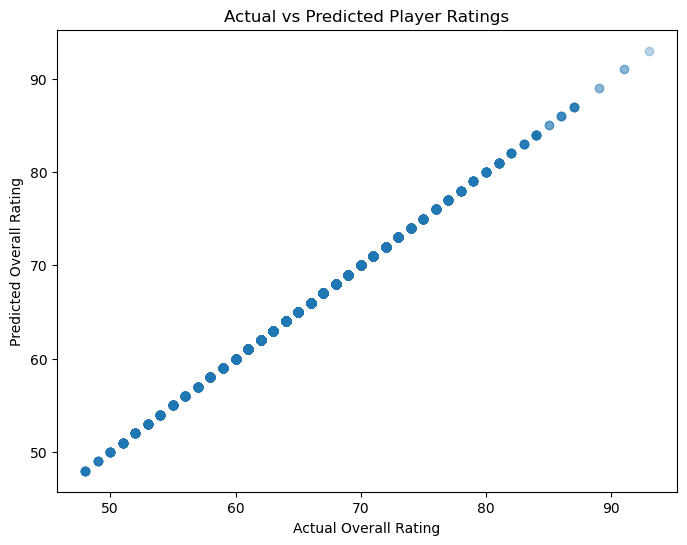

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Overall Rating")
plt.ylabel("Predicted Overall Rating")
plt.title("Actual vs Predicted Player Ratings")

plt.show()

## Random Forest Model

In [76]:
from sklearn.ensemble import RandomForestRegressor

In [77]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [78]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [79]:
rf_pred = rf_model.predict(X_test)

In [80]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 0.0006471816283924928
Random Forest RMSE: 0.030935315368555396
Random Forest R²: 0.9999787696922886


## Detailed Random Forest Model

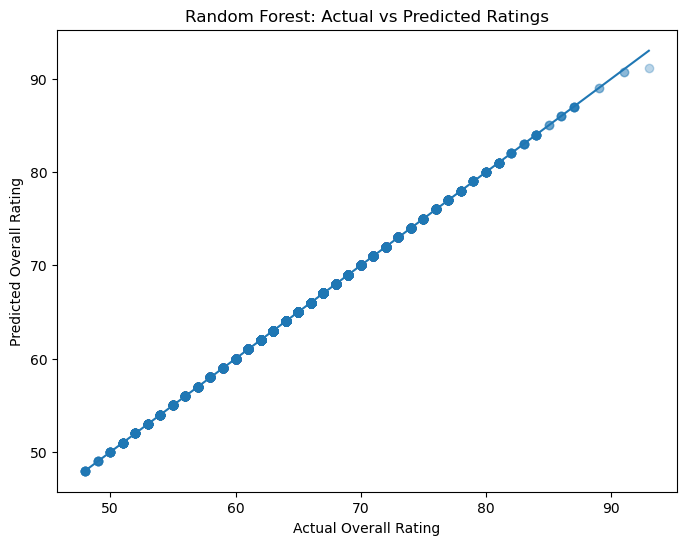

In [81]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_pred, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Overall Rating")
plt.ylabel("Predicted Overall Rating")
plt.title("Random Forest: Actual vs Predicted Ratings")

plt.show()

In [82]:
detailed_features = [
    "Crossing",
    "Finishing",
    "HeadingAccuracy",
    "ShortPassing",
    "Volleys",
    "Dribbling",
    "Curve",
    "FKAccuracy",
    "LongPassing",
    "BallControl",
    "Acceleration",
    "SprintSpeed",
    "Agility",
    "Reactions",
    "Balance",
    "ShotPower",
    "Jumping",
    "Stamina",
    "Strength",
    "LongShots",
    "Aggression",
    "Interceptions",
    "Positioning",
    "Vision",
    "Penalties",
    "Composure",
    "Marking",
    "StandingTackle",
    "SlidingTackle",
    "GKDiving",
    "GKHandling",
    "GKKicking",
    "GKPositioning",
    "GKReflexes"
]

X_detailed = df[detailed_features]
y = df["Overall"]

In [83]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_detailed,
    y,
    test_size=0.2,
    random_state=42
)

In [84]:
rf_detailed = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_detailed.fit(X_train_d, y_train_d)

RandomForestRegressor(random_state=42)

In [85]:
detailed_pred = rf_detailed.predict(X_test_d)

In [86]:
detailed_mae = mean_absolute_error(y_test_d, detailed_pred)

detailed_rmse = np.sqrt(
    mean_squared_error(y_test_d, detailed_pred)
)

detailed_r2 = r2_score(
    y_test_d,
    detailed_pred
)

print("Detailed Random Forest MAE:", detailed_mae)
print("Detailed Random Forest RMSE:", detailed_rmse)
print("Detailed Random Forest R²:", detailed_r2)

Detailed Random Forest MAE: 0.8857150313152402
Detailed Random Forest RMSE: 1.18792834270018
Detailed Random Forest R²: 0.9686939927247571


In [87]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    rf_detailed,
    X_test_d,
    y_test_d,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

## Feature Importance

In [88]:
perm_df = pd.DataFrame({
    "Feature": detailed_features,
    "Importance": perm_importance.importances_mean
})

perm_df = perm_df.sort_values(
    by="Importance",
    ascending=False
)

perm_df.head(15)

,Feature,Importance
13,Reactions,0.364273
9,BallControl,0.103033
27,StandingTackle,0.030101
0,Crossing,0.025805
21,Interceptions,0.015966
32,GKPositioning,0.012735
26,Marking,0.011594
22,Positioning,0.010378
2,HeadingAccuracy,0.009953
28,SlidingTackle,0.008985


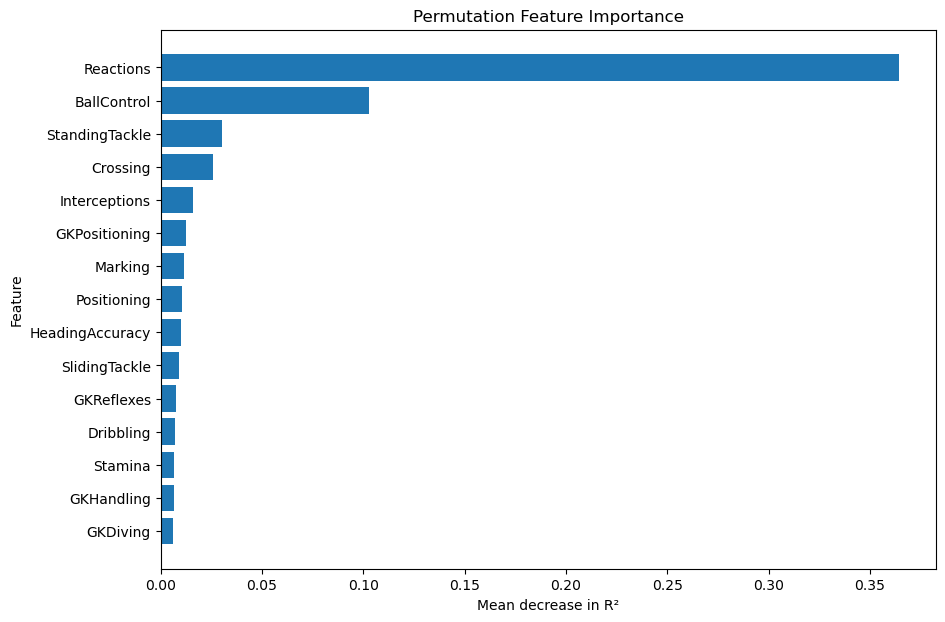

In [89]:
plt.figure(figsize=(10, 7))

top_perm = perm_df.head(15)

plt.barh(
    top_perm["Feature"],
    top_perm["Importance"]
)

plt.xlabel("Mean decrease in R²")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [90]:
import joblib

joblib.dump(rf_detailed, "player_rating_model.pkl")

['player_rating_model.pkl']

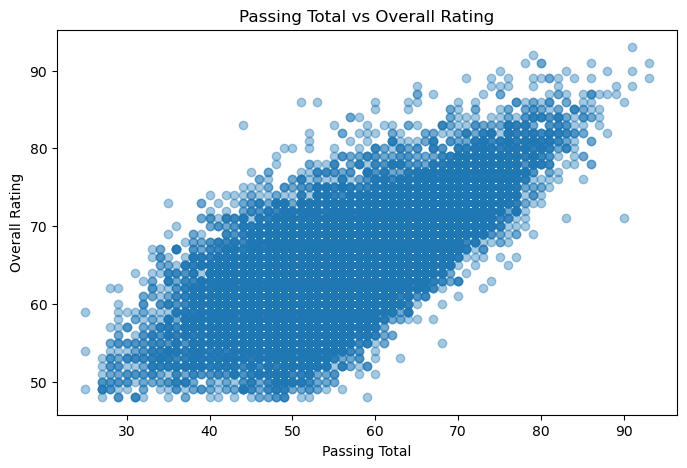

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["PassingTotal"],
    df["Overall"],
    alpha=0.4
)

plt.xlabel("Passing Total")
plt.ylabel("Overall Rating")
plt.title("Passing Total vs Overall Rating")

plt.show()

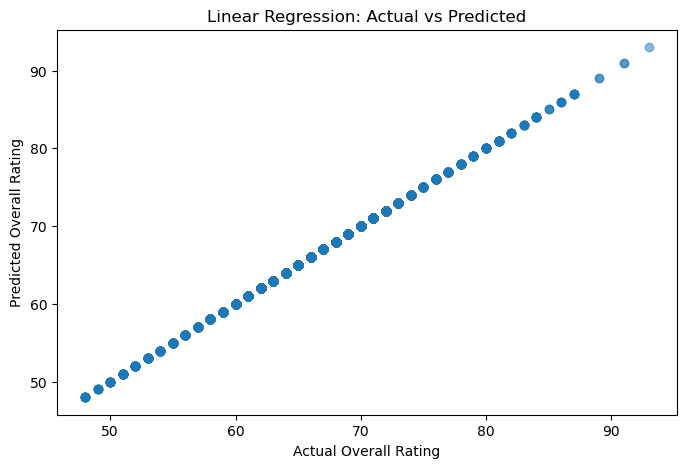

In [92]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Overall Rating")
plt.ylabel("Predicted Overall Rating")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

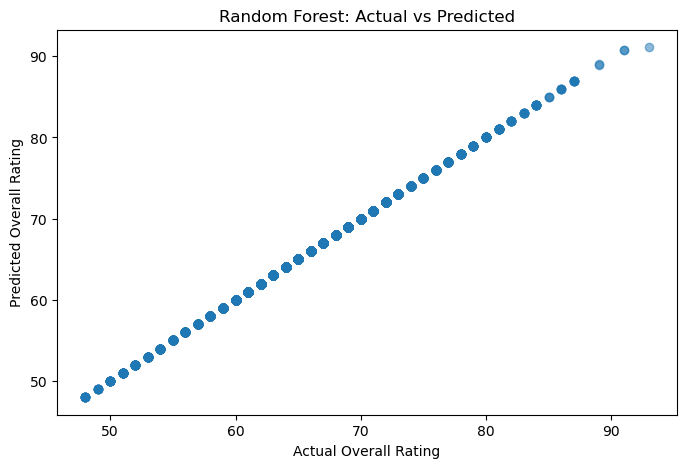

In [93]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.5
)

plt.xlabel("Actual Overall Rating")
plt.ylabel("Predicted Overall Rating")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

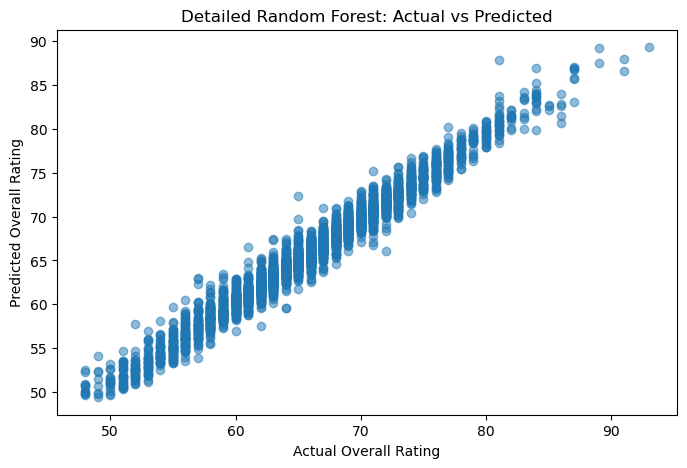

In [94]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test_d,
    detailed_pred,
    alpha=0.5
)

plt.xlabel("Actual Overall Rating")
plt.ylabel("Predicted Overall Rating")
plt.title("Detailed Random Forest: Actual vs Predicted")

plt.show()

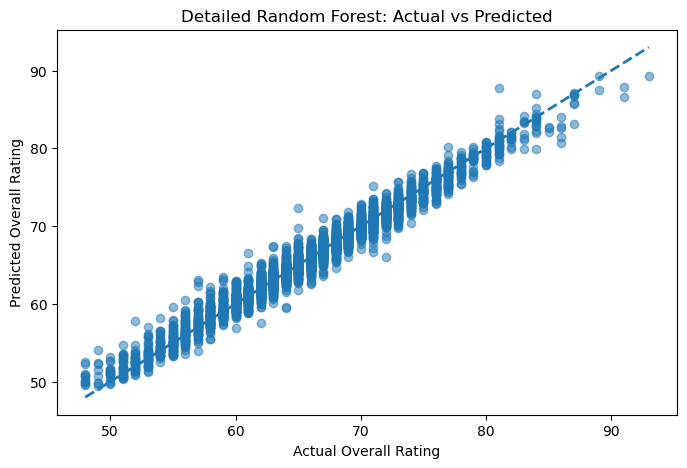

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test_d,
    detailed_pred,
    alpha=0.5
)

# Perfect prediction line
plt.plot(
    [y_test_d.min(), y_test_d.max()],
    [y_test_d.min(), y_test_d.max()],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Overall Rating")
plt.ylabel("Predicted Overall Rating")
plt.title("Detailed Random Forest: Actual vs Predicted")

plt.show()

In [96]:
import joblib

joblib.dump(rf_detailed, "player_rating_model.pkl")

['player_rating_model.pkl']